In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df_1 = pd.read_csv("../data/processed/ipo_master_returns.csv")
df_2 = pd.read_csv("../data/processed/ipo_clean.csv")

print(df_1.shape)
print(df_1.columns.tolist())
print(df_2.shape)
print(df_2.columns.tolist())

(397, 41)
['Unnamed: 0', 'nse_symbol', 'company_name', 'listing_date', 'issue_price', 'listing_price', 'pop_pct', 'close_6mo', 'close_1yr', 'close_2yr', 'close_3yr', 'return_6mo', 'return_1yr', 'return_2yr', 'return_3yr', 'cagr_6mo', 'cagr_1yr', 'cagr_2yr', 'cagr_3yr', 'nifty_close_6mo', 'nifty_close_1yr', 'nifty_close_2yr', 'nifty_close_3yr', 'nifty_close_listing', 'nifty_return_6mo', 'relative_return_6mo', 'nifty_return_1yr', 'relative_return_1yr', 'nifty_return_2yr', 'relative_return_2yr', 'nifty_return_3yr', 'relative_return_3yr', 'nifty_cagr_6mo', 'relative_cagr_6mo', 'nifty_cagr_1yr', 'relative_cagr_1yr', 'nifty_cagr_2yr', 'relative_cagr_2yr', 'nifty_cagr_3yr', 'relative_cagr_3yr', 'listing_year']
(397, 11)
['company_name', 'nse_symbol', 'listing_date', 'issue_price', 'listing_price', 'issue_size_crores', 'QIB', 'HNI', 'RII', 'Total', 'pop_pct']


In [2]:
merge_cols = ['nse_symbol','issue_size_crores', 'QIB', 'HNI', 'RII', 'Total']

df = df_1.merge(df_2[merge_cols], on='nse_symbol', how='left')

print(df.shape)
df[['nse_symbol', 'pop_pct','issue_size_crores', 'QIB', 'HNI', 'RII', 'Total']].head(10)

(397, 46)


,nse_symbol,pop_pct,issue_size_crores,QIB,HNI,RII,Total
0,GKSL,5.921053,250.80,1.06,5.73,19.04,5.21
1,KSHINTL,-3.645833,644.45,1.06,0.42,0.86,0.83
2,ICICIAMC,20.378753,10602.70,123.87,22.04,2.53,39.17
3,NEPHROPLUS,6.891304,871.05,27.47,24.27,2.31,13.96
4,PARKHOSPS,-3.950617,920.00,11.48,15.15,3.16,8.10
5,WAKEFIT,0.000000,1288.89,3.04,1.05,3.17,2.52
6,CORONA,36.723164,655.37,278.52,208.88,28.73,137.04
7,AEQUS,12.903226,922.01,120.92,80.62,78.05,101.63
8,MEESHO,45.225225,5421.20,120.18,38.15,19.04,79.02
9,VIDYAWIRES,0.250000,300.01,5.12,51.98,27.86,26.59


In [3]:
df[['issue_size_crores', 'QIB', 'HNI', 'RII', 'Total']].isnull().sum()

issue_size_crores    0
QIB                  0
HNI                  0
RII                  0
Total                0
dtype: int64

In [4]:
cols = ['pop_pct','issue_size_crores', 'QIB', 'HNI', 'RII', 'Total']
df[cols].describe()

,pop_pct,issue_size_crores,QIB,HNI,RII,Total
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,20.646495,1628.479521,66.849345,86.022191,22.184660,48.531259
std,34.767695,2920.260703,74.453700,146.961063,39.544628,59.600826
min,-38.888889,23.000000,0.000000,0.030000,0.000000,0.110000
25%,0.000000,429.000000,4.180000,2.400000,2.080000,3.060000
50%,9.090909,700.000000,35.660000,25.610000,7.540000,23.890000
75%,32.027257,1500.000000,115.770000,97.420000,23.710000,73.250000
max,252.760736,27858.800000,420.570000,958.070000,374.810000,326.490000


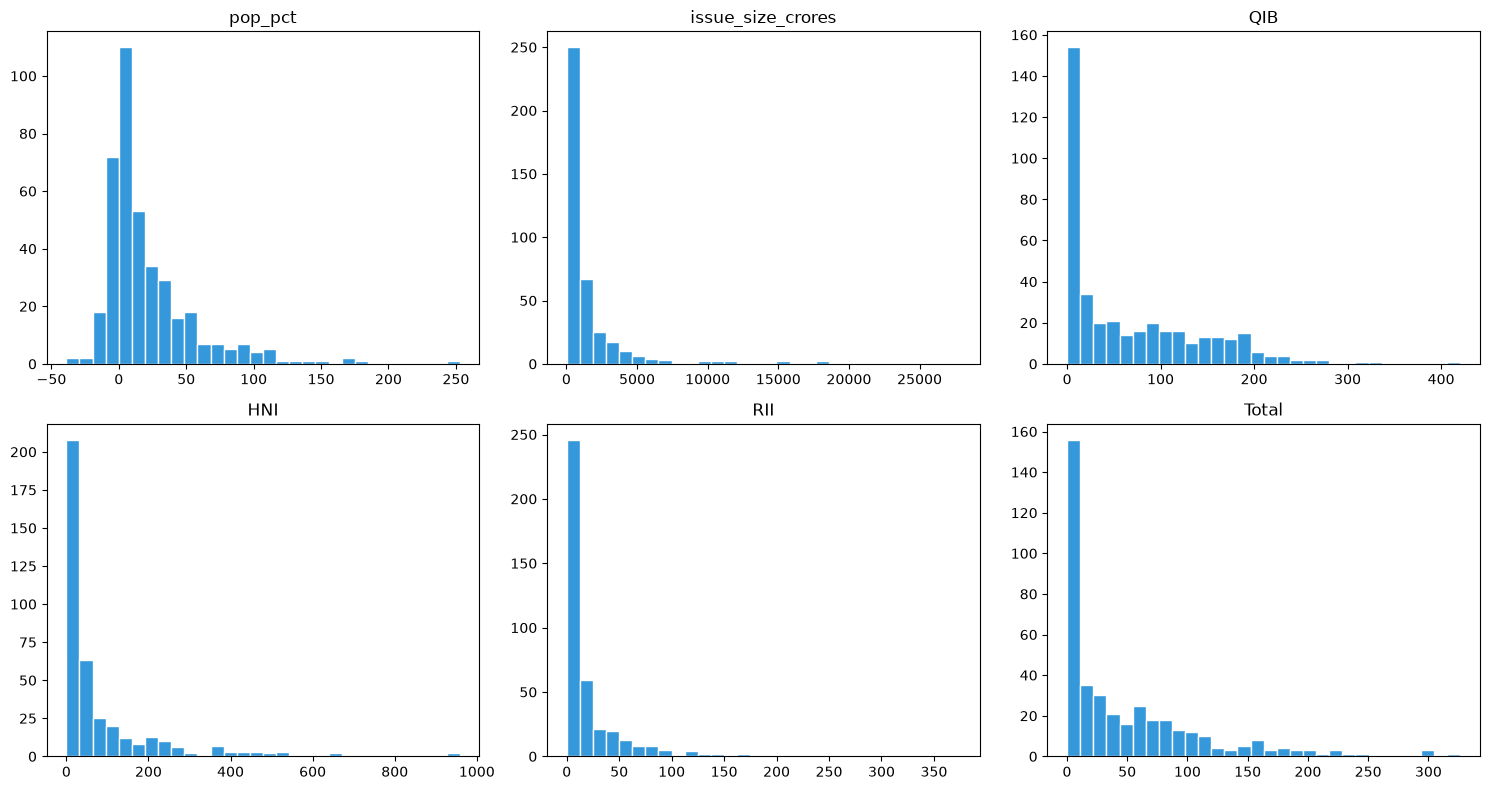

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [6]:
horizon_cols = ["relative_cagr_6mo", "relative_cagr_1yr", "relative_cagr_2yr", "relative_cagr_3yr"]

horizon_cutoff_year = {
    "relative_cagr_6mo": 2025,
    "relative_cagr_1yr": 2024,
    "relative_cagr_2yr": 2023,
    "relative_cagr_3yr": 2022,
}

def mature_subset(df, horizon_col):
    """Return only rows from listing years fully matured for this horizon."""
    max_year = horizon_cutoff_year[horizon_col]
    return df[df["listing_year"] <= max_year]

In [11]:
from scipy.stats import spearmanr
correlation_rows = []

for horizon in horizon_cols:
    sub = mature_subset(df, horizon)
    for factor in cols:
        corr, p_value = spearmanr(sub[factor], sub[horizon])
        correlation_rows.append({
            "factor": factor,
            "horizon": horizon,
            "n": len(sub),
            "spearman_corr": corr,
            "p_value": p_value
        })

correlation_results = pd.DataFrame(correlation_rows)
correlation_pivot = correlation_results.pivot(index="factor", columns="horizon", values="spearman_corr")
correlation_pivot = correlation_pivot[horizon_cols]
correlation_pivot

horizon,relative_cagr_6mo,relative_cagr_1yr,relative_cagr_2yr,relative_cagr_3yr
factor,,,,
HNI,-0.076820,-0.101442,-0.114981,-0.107067
QIB,0.032518,0.018282,-0.034300,-0.075984
RII,-0.076536,-0.080445,-0.106268,-0.108336
Total,-0.029621,-0.059781,-0.093188,-0.115709
issue_size_crores,0.140093,0.029234,0.000959,-0.047553
pop_pct,0.038467,-0.019869,-0.092388,-0.108886


In [17]:
correlation_results_display = correlation_results.copy()
correlation_results_display["significanct"] = correlation_results_display["p_value"] < 0.05
correlation_results_display.sort_values(["horizon", "factor"])

,factor,horizon,n,spearman_corr,p_value,significanct
9,HNI,relative_cagr_1yr,292,-0.101442,0.083547,False
8,QIB,relative_cagr_1yr,292,0.018282,0.755737,False
10,RII,relative_cagr_1yr,292,-0.080445,0.170386,False
11,Total,relative_cagr_1yr,292,-0.059781,0.308648,False
7,issue_size_crores,relative_cagr_1yr,292,0.029234,0.618824,False
6,pop_pct,relative_cagr_1yr,292,-0.019869,0.735293,False
15,HNI,relative_cagr_2yr,211,-0.114981,0.095753,False
14,QIB,relative_cagr_2yr,211,-0.034300,0.620307,False
16,RII,relative_cagr_2yr,211,-0.106268,0.123849,False
17,Total,relative_cagr_2yr,211,-0.093188,0.177491,False


In [22]:
def tercile_analysis(df, col, horizon_col):
    sub = mature_subset(df, horizon_col)[[col, horizon_col]].dropna()
    sub['tercile'] = pd.qcut(sub[col], q=3, labels=["Low", "Mid", "High"])
    return sub.groupby('tercile')[horizon_col].agg(["median", "mean", "count"])

# Pop% terciles across all horizons
for horizon in horizon_cols:
    print(f"{horizon}:")
    print(tercile_analysis(df, "pop_pct", horizon))
    print()

relative_cagr_6mo:
            median       mean  count
tercile                             
Low     -24.927921   1.964163    133
Mid     -16.860216  32.280347    132
High    -23.106346  31.041666    132

relative_cagr_1yr:
            median      mean  count
tercile                            
Low     -13.235349 -8.128096     98
Mid     -12.560932 -0.595528     97
High    -18.132579 -0.089946     97

relative_cagr_2yr:
            median       mean  count
tercile                             
Low     -12.342943  -5.755274     71
Mid     -11.186794  -7.455581     70
High    -21.764296 -14.612818     70

relative_cagr_3yr:
            median       mean  count
tercile                             
Low     -11.957672  -5.459925     52
Mid      -6.674881  -4.427335     51
High    -16.548955 -15.946900     51



In [23]:
other_factors = ['issue_size_crores','QIB', 'HNI', 'RII', 'Total']

for factor in other_factors:
    print(f"{factor} :--")
    for horizon in horizon_cols:
        print(f"{horizon} :")
        print(tercile_analysis(df, factor, horizon))
        print()

issue_size_crores :--
relative_cagr_6mo :
            median       mean  count
tercile                             
Low     -34.611138  -5.460448    133
Mid     -25.222033  41.322678    132
High    -11.635752  29.480194    132

relative_cagr_1yr :
            median      mean  count
tercile                            
Low     -14.110068 -9.699637     98
Mid     -17.578945  3.747562     97
High    -10.634422 -2.845293     97

relative_cagr_2yr :
            median       mean  count
tercile                             
Low     -18.527111 -11.900376     71
Mid      -7.613802  -4.026131     70
High    -19.613183 -11.809379     70

relative_cagr_3yr :
            median       mean  count
tercile                             
Low     -11.254666 -10.232658     52
Mid     -10.369280  -4.264619     51
High    -17.335081 -11.243302     51

QIB :--
relative_cagr_6mo :
            median       mean  count
tercile                             
Low     -22.389544  19.012820    133
Mid     -25.781265  

In [25]:
def tercile_gap(df, cols, horizon_col='relative_cagr_3yr'):
    sub = mature_subset(df, horizon_col)[[cols, horizon_col]].dropna()
    sub['tercile'] = pd.qcut(sub[cols], q=3, labels=['Low', 'Mid', 'High'])
    medians = sub.groupby('tercile')[horizon_col].median()
    return medians['High'] - medians['Low']

summary_table = correlation_pivot[['relative_cagr_3yr']].rename(columns={'relative_cagr_3yr': 'spearman_corr_3yr'})
summary_table = summary_table.reindex(cols)
summary_table['tercile_gap_high_minus_low_3yr'] = [tercile_gap(df, f) for f in cols]
summary_table = summary_table.sort_values('tercile_gap_high_minus_low_3yr')
summary_table

horizon,spearman_corr_3yr,tercile_gap_high_minus_low_3yr
factor,,
QIB,-0.075984,-8.543358
issue_size_crores,-0.047553,-6.080415
HNI,-0.107067,-4.775222
pop_pct,-0.108886,-4.591282
Total,-0.115709,-4.207883
RII,-0.108336,-3.839138


In [26]:
from scipy.stats import linregress

sub = mature_subset(df, 'relative_cagr_2yr')[['pop_pct', 'relative_cagr_2yr']].dropna()

slope, intercept, r_value, p_value, std_err = linregress(sub['pop_pct'], sub['relative_cagr_2yr'])

r_squared = r_value ** 2

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R: {r_value:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"n: {len(sub)}")

Slope: -0.1375
Intercept: -6.0596
R: -0.1358
R-squared: 0.0184
p-value: 0.0488
n: 211


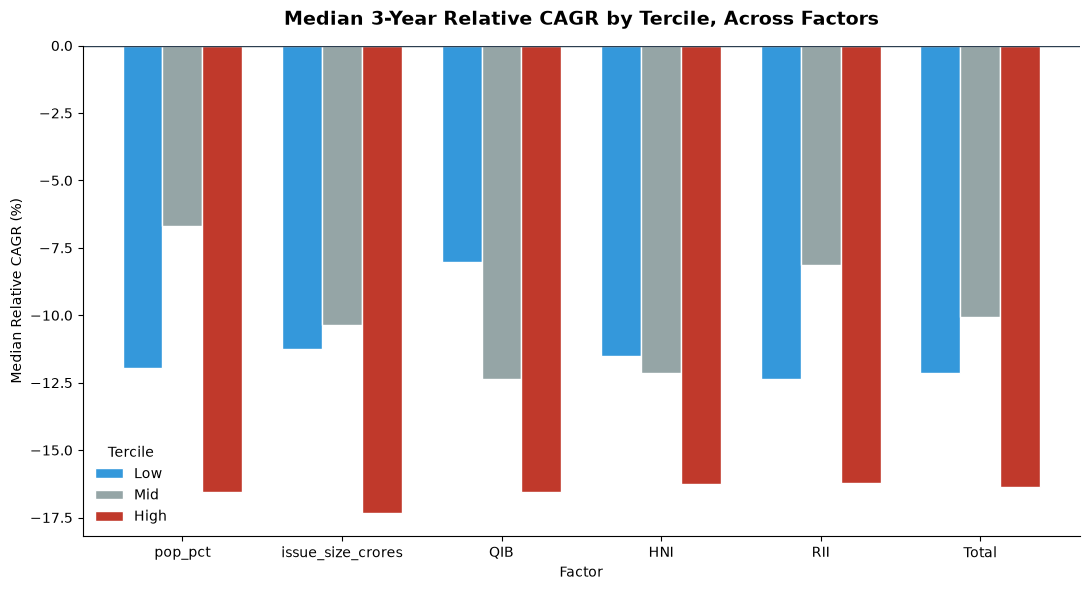

In [28]:
tercile_data = {}
for factor in cols:
    sub = mature_subset(df, 'relative_cagr_3yr')[[factor, 'relative_cagr_3yr']].dropna()
    sub['tercile'] = pd.qcut(sub[factor], q=3, labels=['Low', 'Mid', 'High'])
    tercile_data[factor] = sub.groupby('tercile')['relative_cagr_3yr'].median()

tercile_df = pd.DataFrame(tercile_data)

fig, ax = plt.subplots(figsize=(11, 6))
tercile_df.T.plot(kind='bar', ax=ax, color=['#3498db', '#95a5a6', '#c0392b'], edgecolor='white', width=0.75)

ax.axhline(0, color='#2c3e50', linewidth=1)
ax.set_title('Median 3-Year Relative CAGR by Tercile, Across Factors', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Factor')
ax.set_ylabel('Median Relative CAGR (%)')
ax.legend(title='Tercile', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
correlation_pivot.to_csv('../data/processed/pop_correlation_summary.csv')
summary_table.to_csv('../data/processed/factor_comparison_summary.csv')

## Step 5 Summary: Pop % and Listing-Day Signals vs. Long-Term Performance (Part B)

Tested whether listing day pop%, issue size, and subscription levels (QIB/HNI/RII/Total) predict long term performance relative to Nifty, using Spearman correlation, tercile bucket comparisons, and linear regression across all four horizons (6mo/1yr/2yr/3yr), applying the same mature-cohort filtering from Part A.

**Findings:**

- **No factor shows a meaningful linear correlation with long-term relative performance.** Every Spearman correlation across pop%, issue size, and all four subscription categories stayed between -0.12 and +0.14 at every horizon, and nearly all were statistically insignificant, the sole exception was issue size at 6mo (r = 0.14, p = 0.005), a weak effect that disappeared by the 1-year mark.
- **A linear regression of pop% on 2-year relative CAGR returned R² = 1.84%** (p = 0.049) ,technically significant given the sample size, but practically negligible. Listing-day pop explains under 2% of the variation in long-term performance.
- **Despite flat correlations, tercile analysis reveals a consistent non-linear pattern: the top third of IPOs by pop%, issue size, or any subscription category are the worst 3-year performers**, more consistently than any other tercile. Every single factor tested showed a negative "High minus Low" tercile gap at 3yr, with QIB showing the largest gap (-8.5 percentage points) despite having one of the weakest raw correlations, a clear case of a real, non-linear relationship a single correlation coefficient completely misses.
- **The most-hyped, most heavily subscribed IPOs are not better long-term investments, if anything, the opposite holds at the extremes**, consistent with a mean-reversion story: strong initial demand invites the sharpest long-term correction.

**Limitation:** tercile analysis reveals pattern, not proof of causation, factors like issue size, subscription levels, and listing pop are all correlated with each other and with broader market sentiment at the time of listing, so this doesn't isolate one factor's independent effect on returns.